In [1]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import warnings
warnings.filterwarnings('ignore')

from collections          import Counter
from sklearn.cluster      import KMeans
from pyclustering.utils import timedcall;
from Dataprepare.data_processing import D


In [2]:
features=[
 'balance',
 'purchases',
 'oneoff_purchases',
 'installments_purchases'
]
data=D[features]
print(data.shape)
print(data.head(2))

(8636, 4)
    balance  purchases  oneoff_purchases  installments_purchases
0 -1.334707  -0.123312         -0.996024                0.381976
1  0.952729  -1.686451         -0.996024               -1.096108


Time for 10 samples: 1.8877 seconds
Time for 50 samples: 0.0028 seconds
Time for 100 samples: 0.0041 seconds
Time for 200 samples: 0.0029 seconds
Time for 500 samples: 0.0037 seconds
Time for 1000 samples: 0.0026 seconds
Time for 2000 samples: 0.0030 seconds
Time for 5000 samples: 0.0045 seconds
Time for 8000 samples: 0.0051 seconds


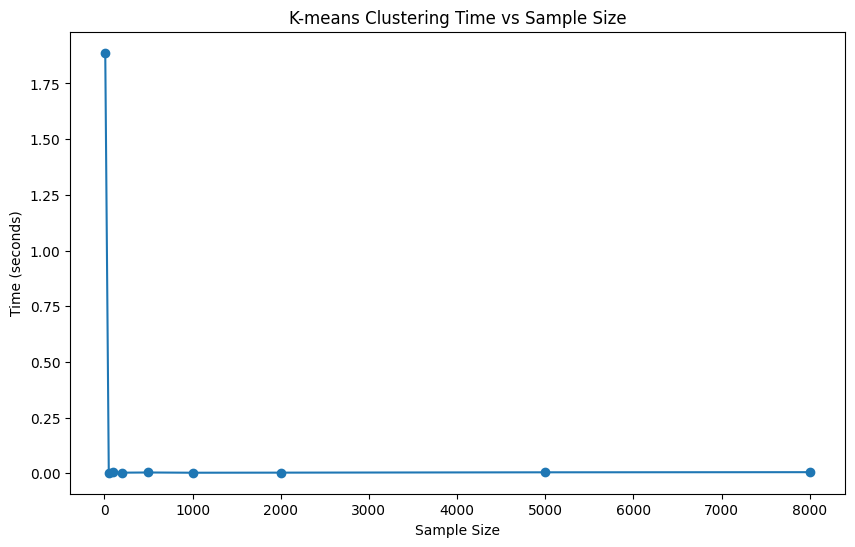

In [3]:
sample_sizes = [10,50,100,200,500,1000,2000,5000,8000]
#Kmeans show ra plt
k     = 3
times=[]
for size in sample_sizes:
    data_sample = data.sample(size)
    (ticks,results) = timedcall(KMeans(n_clusters = k).fit, data_sample)  # xây dựng mô hình
    print(f"Time for {size} samples: {ticks:.4f} seconds")
    times.append(ticks)

plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, times, marker='o')
plt.title('K-means Clustering Time vs Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Time (seconds)')
plt.show()

In [4]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kMeans
##------------------------------------------------------------------------------
k     = 3
Kmeans_model = KMeans(n_clusters = k)
(ticks,results) = timedcall(Kmeans_model.fit, data)  # xây dựng mô hình
print(f"Thời gian chạy: {ticks:.4f} giây")

Thời gian chạy: 0.0115 giây


In [5]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Kmeans_model,'../customer_clustering/Output/kMeans.mdl')

['../customer_clustering/Output/kMeans.mdl']

In [6]:
## Khai thác mô hình đã được xây dựng
Loaded_Kmeans_model = jlb.load('../customer_clustering/Output/kMeans.mdl')

In [7]:
## Các trọng tâm
print(f'*** {k} trọng tâm:')
print(Loaded_Kmeans_model.cluster_centers_)

*** 3 trọng tâm:
[[ 0.46860234 -1.58982617 -0.92801799 -1.07511786]
 [ 0.26756973  0.67753329  0.98902072  0.1602463 ]
 [-0.82415314  0.27122222 -0.78697508  0.65792425]]


In [8]:
## Kết quả gom cụm khách hàng
centroids       = Loaded_Kmeans_model.cluster_centers_
data['cluster'] = Loaded_Kmeans_model.labels_
print(data.head(5))

print('\nKích thước các clusters:', Counter(Loaded_Kmeans_model.labels_))
print('\nClusters lớn nhất:', Counter(Loaded_Kmeans_model.labels_).most_common(1))

    balance  purchases  oneoff_purchases  installments_purchases  cluster
0 -1.334707  -0.123312         -0.996024                0.381976        2
1  0.952729  -1.686451         -0.996024               -1.096108        0
2  0.821135   0.589495          1.049151               -1.096108        1
3  0.233137  -0.717052         -0.124918               -1.096108        0
4  0.651839   0.775749         -0.996024                1.232117        2

Kích thước các clusters: Counter({np.int32(1): 4002, np.int32(2): 2502, np.int32(0): 2132})

Clusters lớn nhất: [(np.int32(1), 4002)]


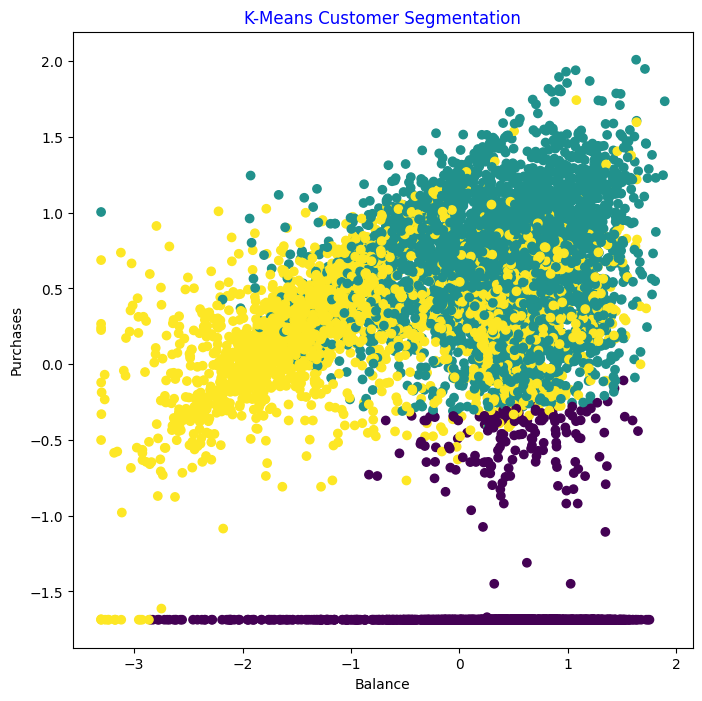

In [9]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
plt.scatter(
    data['balance'],
    data['purchases'],
    c=data['cluster']
)
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()